In [ ]:
%pip install --upgrade --force-reinstall pandas numpy scanpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 45.3 MB/s eta 0:00:0000:0100:01
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached scanpy-1.11.5-py3-none-any.whl (2.1 MB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.1/510.1 kB 34.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 349.3/349.3 kB 38.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 229.9/229.9 kB 25.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 44.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.5/73.5 kB 9.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 46.0 MB/s eta 0:00:0000:0100:01
  Using cached typing_extensions-4.15.0-py3-none-any.whl (44 kB)
  Using cached legacy_api_wrap-1.5-py3-none-any.whl (10 kB)
  Using cached session_info2-0.4.1-py3-none-any.whl (17 kB)
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.2/100.2 kB 10.0 MB/s eta

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker
import matplotlib.cm as cm
import matplotlib as mpl

In [4]:
!tree ./data/

./data/
└── Ath_3h_slim.h5ad

0 directories, 1 file


In [5]:
## 1. Load required data
adata = sc.read_h5ad("data/Ath_3h_slim.h5ad")

In [ ]:
# Print the object summary to check your metadata slots
adata

AnnData object with n_obs × n_vars = 146597 × 30620
    obs: 'orig.ident', 'nCount_RNA', 'nFeature_RNA', 'percent.mito', 'RNA_snn_res.0.8', 'seurat_clusters', 'group_clusters', 'celltype', 'group_celltype', 'metacell_grouping', 'pos_regulon_score', 'neg_regulon_score', 'group'
    var: 'gene_names'
    uns: 'celltype_colors'
    obsm: 'X_pca', 'X_umap'
    layers: 'counts'

In [9]:
adata.var

# Save to CSV
adata.var.to_csv("umap_genes.csv")

In [ ]:
# Save to CSV
adata.var.to_csv("adata_var.csv")

In [6]:
## 3. FacetDotPlot Custom Function
def facet_dot_plot(
    adata,
    features,
    group_by="celltype",
    split_by="group",
    dot_scale=8,
    viridis_option="viridis"
):
    if isinstance(features, str):
        features = [features]
        
    expr_matrix = adata[:, features].to_df()
    metadata = adata.obs[[group_by, split_by]].copy()
    df = pd.concat([expr_matrix, metadata], axis=1)
    
    df_long = df.melt(
        id_vars=[group_by, split_by], 
        value_vars=features, 
        var_name="gene", 
        value_name="expr"
    )
    
    plot_data = df_long.groupby([group_by, split_by, "gene"]).agg(
        avg_exp=("expr", "mean"),
        pct_exp=("expr", lambda x: (x > 0).mean() * 100)
    ).reset_index()
    
    groups = plot_data[split_by].unique()
    ncol = min(4, len(groups))
    
    g = sns.FacetGrid(plot_data, col=split_by, col_wrap=ncol, margin_titles=True, height=4, aspect=1)
    
    def scatter_mapping(data, **kwargs):
        scatter = plt.scatter(
            x=data[group_by],
            y=data["gene"],
            s=data["pct_exp"] * (dot_scale ** 2 / 100), 
            c=data["avg_exp"],
            cmap=viridis_option,
            edgecolors="none"
        )
        return scatter

    g.map_dataframe(scatter_mapping)
    
    for ax in g.axes.flat:
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
        ax.grid(False) 
        ax.set_facecolor('white')
        for spine in ax.spines.values():
            spine.set_color('black')
            spine.set_visible(True)
            
    path_coll = g.axes[0].collections[0] if g.axes[0].collections else None
    if path_coll:
        cbar_ax = g.figure.add_axes([1.02, 0.3, 0.02, 0.4])
        plt.colorbar(path_coll, cax=cbar_ax, label="Average\nexpression")
        
    g.set_axis_labels("", "")
    g.set_titles(col_template="{col_name}")
    
    plt.tight_layout()
    plt.show()
    return g

/tmp/ipykernel_10939/679022301.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  plot_data = df_long.groupby([group_by, split_by, "gene"]).agg(
/tmp/ipykernel_10939/679022301.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/tmp/ipykernel_10939/679022301.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='center')
/tmp/ipykernel_10939/679022301.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.g

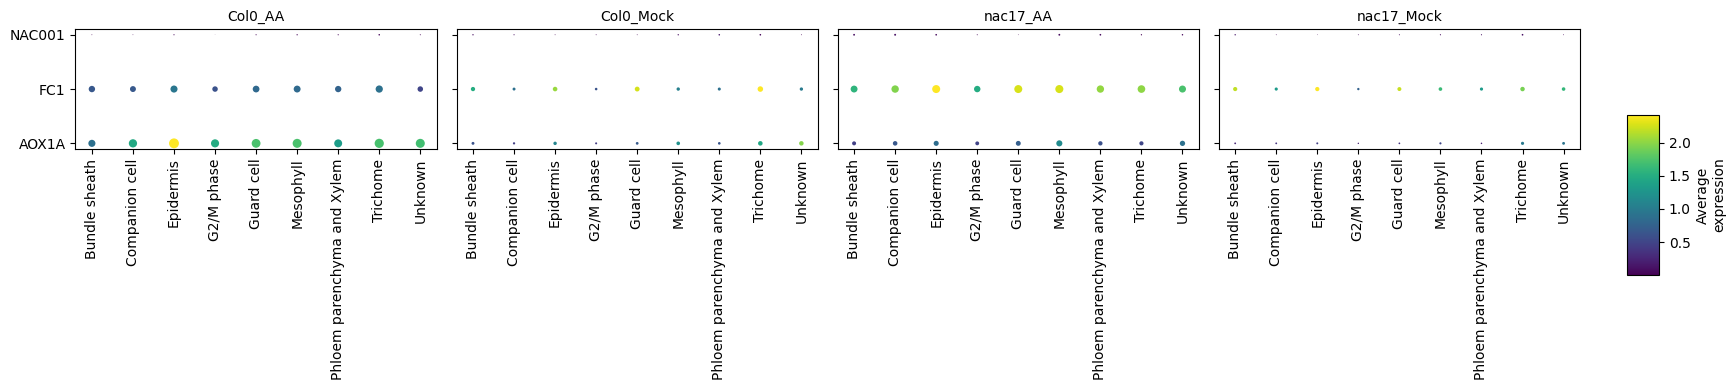

In [8]:
# 4. Generate the plot
facet_dot_plot(
    adata=adata,
    features=["FC1", "AOX1A", "NAC001"],
    group_by="celltype",
    split_by="group",
    viridis_option="viridis",
    dot_scale=8
)

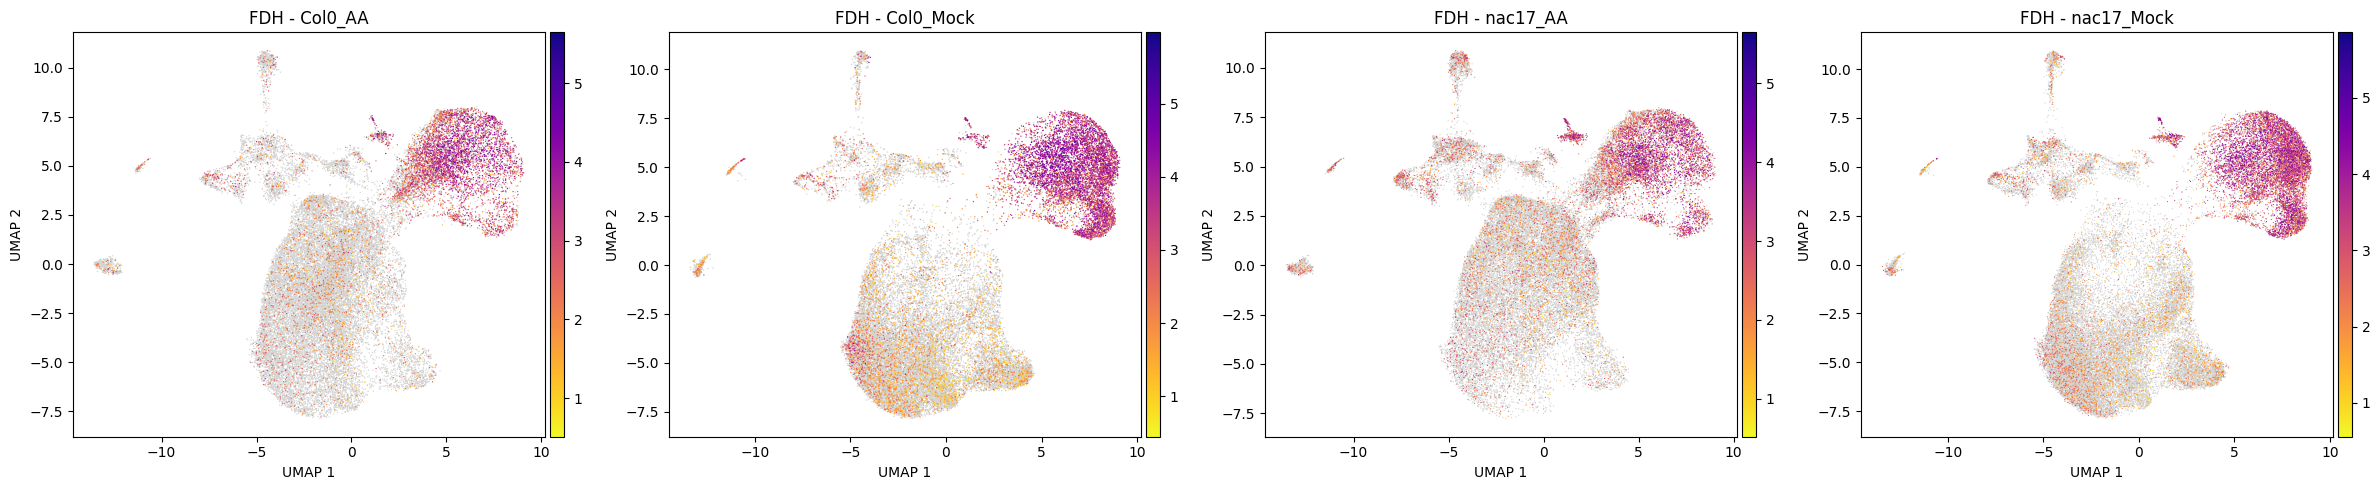

In [ ]:
# Set your R-equivalent Cutoffs
na_cutoff = 1e-09
na_color = "lightgray"

# Get the unique groups present in your metadata
unique_groups = adata.obs['group'].unique()
fig, axes = plt.subplots(1, len(unique_groups), figsize=(6 * len(unique_groups), 5))

if len(unique_groups) == 1:
    axes = [axes]

for i, group_name in enumerate(unique_groups):
    # Subset data for the specific group
    adata_subset = adata[adata.obs['group'] == group_name].copy()
    
    # 1. Pull the gene expression values for 'FDH'
    # Scanpy stores expression in .obs_vector(). We convert it to a float array.
    expr_values = adata_subset.obs_vector("FDH").astype(float)
    
    # 2. Apply the R cutoff: Mask any values less than or equal to 1e-09 as NaN
    expr_values[expr_values <= na_cutoff] = np.nan
    
    # 3. Add this modified custom column temporarily back into the subset metadata
    adata_subset.obs["FDH_masked"] = expr_values

    # 4. Create and configure the reversed plasma colormap to handle NaNs (NA values)
    # We fetch 'plasma_r' and tell it to color any 'bad' (NaN) values as lightgray
    current_cmap = mpl.colormaps["plasma_r"].copy()
    current_cmap.set_bad(color=na_color)

    # 5. Plot using Scanpy with our masked color data and custom colormap
    sc.pl.umap(
        adata_subset,
        color="FDH_masked",
        ax=axes[i],
        show=False,
        title=f"FDH - {group_name}",
        cmap=current_cmap,
        frameon=True
    )
    
    # --- FORCE NUMBERS AND TICK MARKS TO RE-APPEAR ---
    axes[i].xaxis.set_major_locator(ticker.AutoLocator())
    axes[i].yaxis.set_major_locator(ticker.AutoLocator())
    axes[i].tick_params(axis='both', which='both', bottom=True, left=True, labelbottom=True, labelleft=True)
    axes[i].set_xlabel("UMAP 1")
    axes[i].set_ylabel("UMAP 2")

plt.tight_layout()
plt.show()